# Unified Agent Comparison Notebook

This notebook provides a unified framework to compare different agents (PRF, Reranking) against BM25 baseline.
Configure parameters in Cell 1 to select which agent to run.

In [8]:
# ============================================================================
# CELL 1: CONSTANTS AND PARAMETERS
# ============================================================================

# ===== FILE PATHS =====
DATA_FILE = "msmarco_queries_50_100_qrels.csv"

# ===== RETRIEVAL PARAMETERS =====
TOP_K = 10
NUM_QUERIES = 5

# ===== AGENT PARAMETERS =====
NUM_EXPANSION_TERMS = 2  # For PRF agent

# ===== AGENT SELECTION =====
# Multi-agent selection: [PRF, Reranking, Reformulate]
# You can select 0 to 2 agents (not more)
# Valid combinations:
#   [0,0,0] = Baseline only
#   [1,0,0] = PRF only
#   [0,1,0] = Reranking only
#   [0,0,1] = Reformulate only
#   [1,1,0] = PRF + Reranking (PRF applied first, then Reranking)
#   [1,0,1] = PRF + Reformulate (not recommended - use one or the other)
#   [0,1,1] = Reformulate + Reranking (Reformulate applied first, then Reranking)
AGENT_SELECTION = [1, 0, 1]  # Change this to select agents

# Validate agent selection
num_selected = sum(AGENT_SELECTION)
if num_selected > 2:
    raise ValueError(f"Maximum 2 agents allowed, but {num_selected} were selected!")

AGENT_NAMES = ["PRF", "Reranking", "Reformulate"]
selected_agents = [AGENT_NAMES[i] for i, selected in enumerate(AGENT_SELECTION) if selected]
agent_combination_name = " + ".join(selected_agents) if selected_agents else "Baseline"

print(f"✓ Configuration loaded")
print(f"  Data file: {DATA_FILE}")
print(f"  Top-K: {TOP_K}")
print(f"  Selected Agent(s): {agent_combination_name}")
print(f"  Number of queries: {NUM_QUERIES}")

✓ Configuration loaded
  Data file: msmarco_queries_50_100_qrels.csv
  Top-K: 10
  Selected Agent(s): PRF + Reformulate
  Number of queries: 5


In [9]:
# ============================================================================
# CELL 2: SETUP - All imports, initialization, and utility functions
# ============================================================================

import sys
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import logging
import matplotlib.pyplot as plt

# Add src to path
src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from sentence_transformers import SentenceTransformer
from src.utils.retriever import Retriever, create_retriever_callable
from src.agents.prf import PRFAgent
from src.agents.rerank import RerankingAgent
from src.agents.reformulate import ReformulationAgent
from src.simulation import Simulation

# Configure logging
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

print("✓ All libraries imported successfully")

# Load the CSV file with qrels
data_path = Path.cwd() / DATA_FILE

if not data_path.exists():
    print(f"⚠️  Warning: CSV not found at {data_path}")
    print(f"Please ensure {DATA_FILE} exists in data directory")
else:
    df_qrels = pd.read_csv(data_path)
    print(f"✓ Loaded qrels CSV with {len(df_qrels)} entries")
    print(f"✓ Unique queries: {df_qrels['query_id'].nunique()}")
    print(f"\nSample entries:")
    print(df_qrels.head())

# Get unique queries
sample_queries = sorted(df_qrels['query_id'].unique())[:NUM_QUERIES]
print(f"\n✓ Will evaluate {len(sample_queries)} queries: {sample_queries}")

# Initialize sentence transformer (for embedding)
print("\nLoading sentence transformer model...")
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✓ Encoder loaded")

# Initialize retriever
print("Setting up retriever...")
retriever_instance = Retriever()
retriever_func = create_retriever_callable(retriever_instance)
print("✓ Retriever initialized")

# Initialize selected agents
print(f"Setting up agents...")
agents = {}
if AGENT_SELECTION[0]:  # PRF
    agents['PRF'] = PRFAgent(embed_model=encoder, num_expansion_terms=NUM_EXPANSION_TERMS)
    print(f"  ✓ PRF agent initialized")
if AGENT_SELECTION[1]:  # Reranking
    agents['Reranking'] = RerankingAgent(embed_model=encoder)
    print(f"  ✓ Reranking agent initialized")
if AGENT_SELECTION[2]:  # Reformulate
    agents['Reformulate'] = ReformulationAgent(embed_model=encoder)
    print(f"  ✓ Reformulate agent initialized")

# Helper function to normalize doc_ids
def normalize_doc_id(doc_id):
    """
    Extract the base doc_id from retriever format.
    Retriever format: msmarco_v2.1_doc_52_1062570315#1_2098008849
    Qrels format: msmarco_v2.1_doc_02_680722105
    Extract the part before # to match qrels format
    """
    if '#' in doc_id:
        return doc_id.split('#')[0]
    return doc_id

# Build lookup dict for graded relevance: (query_id, doc_id) -> relevance
qrels_lookup = {}
for _, row in df_qrels.iterrows():
    qrels_lookup[(row['query_id'], row['doc_id'])] = row['relevance']
print(f"Loaded {len(qrels_lookup)} qrels entries")

# Define NDCG@K Calculation Functions
def compute_dcg(relevances: List[int], k: int = 10) -> float:
    """
    Compute DCG@k given a list of relevance scores.
    
    DCG@k = sum_{i=1}^{k} (2^rel_i - 1) / log2(i + 1)
    """
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        if rel > 0:
            dcg += (2 ** rel - 1) / np.log2(i + 2)  # i+2 because ranking is 1-indexed
    return dcg


def compute_ndcg(graded_relevance: List[int], query_id: str, k: int = 10) -> float:
    """
    Compute NDCG@k.
    
    Args:
        graded_relevance: List of graded relevance scores
        query_id: Query ID for looking up ideal gains
        k: Cutoff for NDCG calculation
    
    Returns:
        NDCG@k score in [0, 1]
    """
    # Compute DCG
    dcg = compute_dcg(graded_relevance, k)
    
    # Compute ideal DCG using actual relevance values for this query
    query_qrels = df_qrels[df_qrels['query_id'] == query_id]
    ideal_gains = sorted(query_qrels['relevance'].values, reverse=True)
    idcg = compute_dcg(ideal_gains, k)
    
    # Compute NDCG
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return ndcg


# ===== AGENT HELPER METHODS =====
def apply_prf_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply PRF agent to expand/modify retrieval results."""
    raw_results = (doc_ids, doc_scores, corpus)
    query_features = {
        'query_text': query_text,
        'retriever': retriever_func,
        'top_k': top_k
    }
    agent_effects = agents['PRF'].compute_effects(query_features, raw_results=raw_results)
    return agent_effects['new_doc_ids']


def apply_reformulate_agent(query_text, top_k):
    """Apply Reformulate agent to rewrite query and retrieve new documents."""
    query_features = {
        'query_text': query_text,
        'retriever': retriever_func,
        'top_k': top_k
    }
    agent_effects = agents['Reformulate'].compute_effects(query_features)
    reformulated_query = agent_effects.get('new_query_text', query_text)
    return agent_effects['new_doc_ids'], reformulated_query


def apply_reranking_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply Reranking agent to reorder documents."""
    query_features = {
        'query_text': query_text,
        'doc_ids': doc_ids,
        'doc_scores': doc_scores,
        'corpus': corpus,
        'top_k_rerank': top_k
    }
    agent_effects = agents['Reranking'].compute_effects(query_features)
    return agent_effects['new_doc_ids']


print("\n✓ Agent helper methods defined")
print("\n" + "="*80)

print("SETUP COMPLETE - Ready for comparison")
print("="*80)

✓ All libraries imported successfully
✓ Loaded qrels CSV with 1277 entries
✓ Unique queries: 18

Sample entries:
   query_id                            query_text  \
0   2005861  what are the three countries in 1984   
1   2005861  what are the three countries in 1984   
2   2005861  what are the three countries in 1984   
3   2005861  what are the three countries in 1984   
4   2005861  what are the three countries in 1984   

                           doc_id  relevance  
0   msmarco_v2.1_doc_00_388740946          1  
1  msmarco_v2.1_doc_01_1066810610          2  
2   msmarco_v2.1_doc_04_943106501          1  
3   msmarco_v2.1_doc_05_695295296          3  
4    msmarco_v2.1_doc_06_74448072          3  

✓ Will evaluate 5 queries: [np.int64(2005861), np.int64(2006211), np.int64(2006394), np.int64(2006627), np.int64(2016333)]

Loading sentence transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 710.01it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Encoder loaded
Setting up retriever...
✓ Retriever initialized
Setting up agents...
  ✓ PRF agent initialized
  ✓ Reformulate agent initialized
Loaded 1277 qrels entries

✓ Agent helper methods defined

SETUP COMPLETE - Ready for comparison


In [10]:
# ============================================================================
# CELL 3: BASELINE - BM25 Retrieval and NDCG Calculation
# ============================================================================

baseline_results_dict = {}
baseline_ndcg_scores = {}
baseline_raw_results = {}  # Store raw results for agent to reuse

print("\n" + "="*80)
print("BASELINE: BM25 RETRIEVAL")
print("="*80)

# Process each query
for query_id in sample_queries:
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Retrieve top k documents
    baseline_doc_ids, baseline_scores, baseline_corpus = retriever_func(query_text, top_k=TOP_K)
    
    # Store raw results for agent to reuse
    baseline_raw_results[query_id] = (baseline_doc_ids, baseline_scores, baseline_corpus)
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in baseline_doc_ids]
    
    baseline_results_dict[query_id] = graded_relevance
    print(f"  Retrieved docs: {baseline_doc_ids[:3]}...")
    print(f"  Normalized: {[normalize_doc_id(d) for d in baseline_doc_ids[:3]]}...")
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    baseline_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print("BASELINE RESULTS")
print("="*80)
for query_id, ndcg in baseline_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

baseline_mean = np.mean(list(baseline_ndcg_scores.values()))
print(f"\nMean Baseline NDCG@{TOP_K}: {baseline_mean:.4f}")


BASELINE: BM25 RETRIEVAL

Query 2005861: what are the three countries in 1984


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_13_267346721#0_631972288', 'msmarco_v2.1_doc_36_598978357#5_1202570400', 'msmarco_v2.1_doc_13_548647086#10_1264381331']...
  Normalized: ['msmarco_v2.1_doc_13_267346721', 'msmarco_v2.1_doc_36_598978357', 'msmarco_v2.1_doc_13_548647086']...
  Graded relevance: [0, 2, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@10: 0.0595

Query 2006211: what does auslan interpreted performance mean


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_10_465221469#0_853187414', 'msmarco_v2.1_doc_10_465221469#1_853189560', 'msmarco_v2.1_doc_33_773946582#2_1613196818']...
  Normalized: ['msmarco_v2.1_doc_10_465221469', 'msmarco_v2.1_doc_10_465221469', 'msmarco_v2.1_doc_33_773946582']...
  Graded relevance: [1, 1, 1, 0, 1, 1, 0, 1, 0, 3]
  NDCG@10: 0.1770

Query 2006394: what does septrin heal?


...

  Retrieved docs: ['msmarco_v2.1_doc_04_667663003#14_1452776484', 'msmarco_v2.1_doc_48_560650934#0_1026477529', 'msmarco_v2.1_doc_00_800449134#0_1486615757']...
  Normalized: ['msmarco_v2.1_doc_04_667663003', 'msmarco_v2.1_doc_48_560650934', 'msmarco_v2.1_doc_00_800449134']...
  Graded relevance: [0, 2, 1, 2, 1, 1, 1, 0, 2, 0]
  NDCG@10: 0.4156

Query 2006627: what is 311 for


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_00_113797779#3_204685247', 'msmarco_v2.1_doc_00_113797779#2_204684237', 'msmarco_v2.1_doc_00_113797779#1_204683323']...
  Normalized: ['msmarco_v2.1_doc_00_113797779', 'msmarco_v2.1_doc_00_113797779', 'msmarco_v2.1_doc_00_113797779']...
  Graded relevance: [0, 0, 0, 3, 0, 2, 3, 2, 2, 1]
  NDCG@10: 0.2690

Query 2016333: how to make ground beef empanadas


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Retrieved docs: ['msmarco_v2.1_doc_55_12974461#2_33211105', 'msmarco_v2.1_doc_47_1182413403#4_2570560213', 'msmarco_v2.1_doc_47_1182413403#3_2570558351']...
  Normalized: ['msmarco_v2.1_doc_55_12974461', 'msmarco_v2.1_doc_47_1182413403', 'msmarco_v2.1_doc_47_1182413403']...
  Graded relevance: [0, 2, 2, 2, 2, 2, 2, 2, 0, 2]
  NDCG@10: 0.5517

BASELINE RESULTS
Query 2005861: NDCG@10 = 0.0595
Query 2006211: NDCG@10 = 0.1770
Query 2006394: NDCG@10 = 0.4156
Query 2006627: NDCG@10 = 0.2690
Query 2016333: NDCG@10 = 0.5517

Mean Baseline NDCG@10: 0.2946


In [11]:
# ============================================================================
# CELL 4: AGENT COMBINATIONS - Apply selected agent pipeline
# ============================================================================

agent_combo_results_dict = {}
agent_combo_ndcg_scores = {}

print("\n" + "="*80)
print(f"AGENT COMBINATION: {agent_combination_name.upper()}")
print("="*80)

# Process each query
for query_id in sample_queries:
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Start with baseline retrieval results
    baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
    
    # If no agents selected, skip processing
    if sum(AGENT_SELECTION) == 0:
        final_doc_ids = baseline_doc_ids
        reformulated_query = None
    else:
        current_doc_ids = baseline_doc_ids
        current_scores = baseline_scores
        current_corpus = baseline_corpus
        reformulated_query = None
        
        # Apply agents in order: Reformulate/PRF first, then Reranking
        if AGENT_SELECTION[2]:  # Reformulate (run first if selected)
            current_doc_ids, reformulated_query = apply_reformulate_agent(query_text, TOP_K)
            print(f"  Reformulated query: {reformulated_query}")
            # Get scores and corpus for reranking
            _, current_scores, current_corpus = retriever_func(query_text, top_k=TOP_K)
        
        elif AGENT_SELECTION[0]:  # PRF (run first if Reformulate not selected)
            current_doc_ids = apply_prf_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
        
        # Apply Reranking if selected (always last if selected with another agent)
        if AGENT_SELECTION[1] and (AGENT_SELECTION[0] or AGENT_SELECTION[2]):
            current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
        
        elif AGENT_SELECTION[1] and not AGENT_SELECTION[0] and not AGENT_SELECTION[2]:  # Reranking only
            current_doc_ids = apply_reranking_agent(query_text, baseline_doc_ids, baseline_scores, baseline_corpus, TOP_K)
        
        final_doc_ids = current_doc_ids
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in final_doc_ids]
    
    agent_combo_results_dict[query_id] = graded_relevance
    print(f"  Final retrieved docs: {final_doc_ids[:3]}...")
    print(f"  Normalized: {[normalize_doc_id(d) for d in final_doc_ids[:3]]}...")
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    agent_combo_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print(f"{agent_combination_name.upper()} RESULTS")
print("="*80)
for query_id, ndcg in agent_combo_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

agent_combo_mean = np.mean(list(agent_combo_ndcg_scores.values()))
print(f"\nMean {agent_combination_name} NDCG@{TOP_K}: {agent_combo_mean:.4f}")


AGENT COMBINATION: PRF + REFORMULATE

Query 2005861: what are the three countries in 1984


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_33_1347699514#6_2883757796', 'msmarco_v2.1_doc_33_1347699514#7_2883759786', 'msmarco_v2.1_doc_33_1320269301#5_2809905460', 'msmarco_v2.1_doc_33_1329675366#10_2835123257', 'msmarco_v2.1_doc_55_200438479#0_467283348', 'msmarco_v2.1_doc_48_1224681744#0_2235212387', 'msmarco_v2.1_doc_13_267346721#0_631972288', 'msmarco_v2.1_doc_49_385436824#12_785014078', 'msmarco_v2.1_doc_33_1325381091#4_2823477681', 'msmarco_v2.1_doc_33_1325381091#5_2823480074'], array([60.950935, 59.091843, 53.174   , 52.793194, 52.25404 , 51.607925,
       51.44239 , 50.529964, 49.28175 , 48.886826], dtype=float32), {'msmarco_v2.1_doc_33_1347699514#6_2883757796': "The Party Has Many Slogans   In George Orwell's 1984, the Party, the government of Oceania, has many slogans. One of the sayings is “Big Brother Is Watching You”. Despite the fact that the slogan is only mentioned a few times throughout the novel, it embodies the government that Orwell has created. We first learn of 

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Final retrieved docs: ['msmarco_v2.1_doc_33_1347699514#6_2883757796', 'msmarco_v2.1_doc_33_1347699514#7_2883759786', 'msmarco_v2.1_doc_33_1320269301#5_2809905460']...
  Normalized: ['msmarco_v2.1_doc_33_1347699514', 'msmarco_v2.1_doc_33_1347699514', 'msmarco_v2.1_doc_33_1320269301']...
  Graded relevance: [0, 0, 2, 0, 0, 3, 0, 0, 0, 0]
  NDCG@10: 0.1256

Query 2006211: what does auslan interpreted performance mean


...

  Final retrieved docs: ['msmarco_v2.1_doc_41_1789594777#0_2804258628', 'msmarco_v2.1_doc_24_1571063431#0_3356309883', 'msmarco_v2.1_doc_41_1789594777#1_2804259958']...
  Normalized: ['msmarco_v2.1_doc_41_1789594777', 'msmarco_v2.1_doc_24_1571063431', 'msmarco_v2.1_doc_41_1789594777']...
  Graded relevance: [3, 2, 3, 3, 3, 3, 3, 2, 2, 3]
  NDCG@10: 0.8431

Query 2016333: how to make ground beef empanadas


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_06_1304659884#0_1729162377', 'msmarco_v2.1_doc_23_185754779#0_421363852', 'msmarco_v2.1_doc_45_552291424#12_976867876', 'msmarco_v2.1_doc_47_1182413403#3_2570558351', 'msmarco_v2.1_doc_25_1294729512#2_2444993297', 'msmarco_v2.1_doc_45_552167539#0_976622076', 'msmarco_v2.1_doc_47_1182413403#4_2570560213', 'msmarco_v2.1_doc_06_1304659884#18_1729188605', 'msmarco_v2.1_doc_45_80939266#2_177699740', 'msmarco_v2.1_doc_55_12974461#1_33209765'], array([64.002014, 63.64927 , 63.480892, 63.074623, 62.253834, 61.813927,
       61.363068, 60.956234, 60.732395, 60.696983], dtype=float32), {'msmarco_v2.1_doc_06_1304659884#0_1729162377': "How to Make Empanadas - Handle the Heat\nFiled Under: Appetizer | Beef | How To | Latin | Lunch | Main Dish | Videos\nHow to Make Empanadas\nRecipe By Tessa Arias\n|\nJune 10th, 2015\n4.86 from 14 votes\n51 Comments\nLeave a Review / Comment\nRead Comments\n4.86 from 14 votes\n51 Comments\nLeave a Review / Comment\nRead Com

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Final retrieved docs: ['msmarco_v2.1_doc_06_1304659884#0_1729162377', 'msmarco_v2.1_doc_23_185754779#0_421363852', 'msmarco_v2.1_doc_45_552291424#12_976867876']...
  Normalized: ['msmarco_v2.1_doc_06_1304659884', 'msmarco_v2.1_doc_23_185754779', 'msmarco_v2.1_doc_45_552291424']...
  Graded relevance: [1, 2, 2, 2, 1, 2, 2, 1, 0, 0]
  NDCG@10: 0.4796

PRF + REFORMULATE RESULTS
Query 2005861: NDCG@10 = 0.1256
Query 2006211: NDCG@10 = 0.3352
Query 2006394: NDCG@10 = 0.1784
Query 2006627: NDCG@10 = 0.8431
Query 2016333: NDCG@10 = 0.4796

Mean PRF + Reformulate NDCG@10: 0.3924



COMPARISON TABLE: BASELINE vs PRF + REFORMULATE

 Query ID Baseline NDCG PRF + Reformulate NDCG  Δ NDCG      Δ %
  2005861        0.0595                 0.1256 +0.0660 +110.98%
  2006211        0.1770                 0.3352 +0.1582  +89.33%
  2006394        0.4156                 0.1784 -0.2371  -57.07%
  2006627        0.2690                 0.8431 +0.5741 +213.44%
  2016333        0.5517                 0.4796 -0.0721  -13.07%

SUMMARY STATISTICS
Baseline Mean NDCG@10: 0.2946
PRF + Reformulate Mean NDCG@10: 0.3924
Mean Improvement: +0.0978
Mean Improvement %: +33.20%
Queries Improved: 3/5


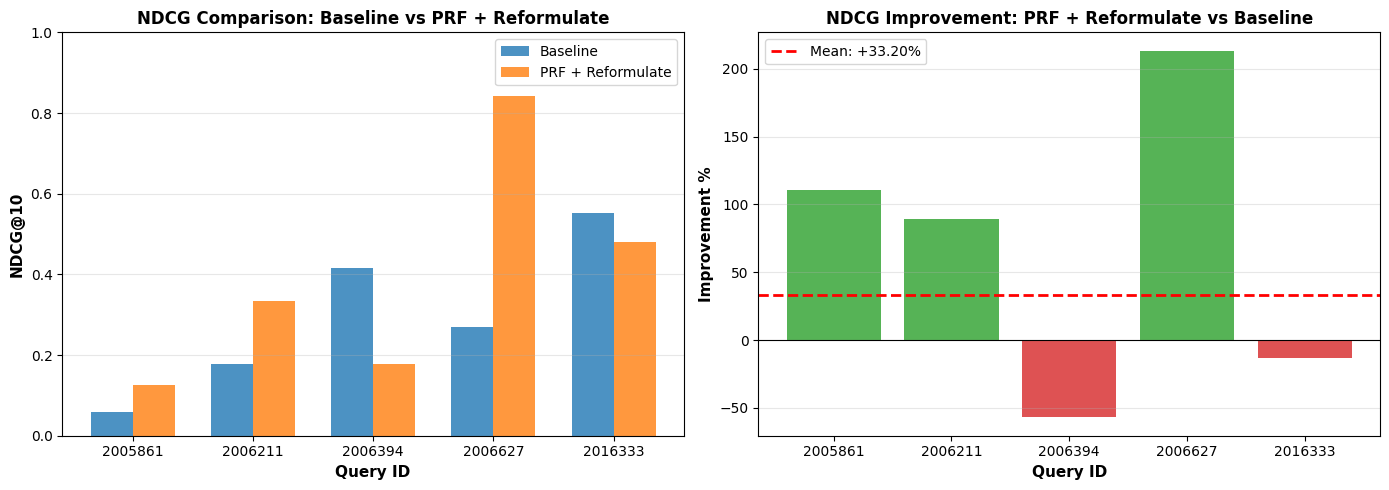


✓ Visualization complete


In [12]:
# ============================================================================
# CELL 5: COMPARATIVE RESULTS TABLE AND VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print(f"COMPARISON TABLE: BASELINE vs {agent_combination_name.upper()}")
print("="*80)

comparison_data = []
for query_id in sample_queries:
    baseline_ndcg = baseline_ndcg_scores[query_id]
    agent_ndcg = agent_combo_ndcg_scores[query_id]
    improvement = agent_ndcg - baseline_ndcg
    improvement_pct = (improvement / baseline_ndcg * 100) if baseline_ndcg > 0 else 0
    
    comparison_data.append({
        'Query ID': query_id,
        'Baseline NDCG': f"{baseline_ndcg:.4f}",
        f'{agent_combination_name} NDCG': f"{agent_ndcg:.4f}",
        'Δ NDCG': f"{improvement:+.4f}",
        'Δ %': f"{improvement_pct:+.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)

# Display all rows (no truncation)
with pd.option_context('display.max_rows', None):
    print("\n" + df_comparison.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
mean_improvement = agent_combo_mean - baseline_mean

print(f"Baseline Mean NDCG@{TOP_K}: {baseline_mean:.4f}")
print(f"{agent_combination_name} Mean NDCG@{TOP_K}: {agent_combo_mean:.4f}")
print(f"Mean Improvement: {mean_improvement:+.4f}")
print(f"Mean Improvement %: {(mean_improvement/baseline_mean*100):+.2f}%")

queries_improved = sum(1 for qid in sample_queries if agent_combo_ndcg_scores[qid] > baseline_ndcg_scores[qid])
print(f"Queries Improved: {queries_improved}/{len(sample_queries)}")
print("="*80)

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: NDCG Comparison Bar Chart
query_ids_str = [str(qid) for qid in sample_queries]
baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
agent_scores = [agent_combo_ndcg_scores[qid] for qid in sample_queries]

x = np.arange(len(query_ids_str))
width = 0.35

axes[0].bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
axes[0].bar(x + width/2, agent_scores, width, label=agent_combination_name, alpha=0.8, color='#ff7f0e')
axes[0].set_xlabel('Query ID', fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'NDCG@{TOP_K}', fontsize=11, fontweight='bold')
axes[0].set_title(f'NDCG Comparison: Baseline vs {agent_combination_name}', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(query_ids_str)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.0])

# Plot 2: Improvement Percentage
improvements = []
colors = []
for qid in sample_queries:
    imp = ((agent_combo_ndcg_scores[qid] - baseline_ndcg_scores[qid]) / baseline_ndcg_scores[qid] * 100) if baseline_ndcg_scores[qid] > 0 else 0
    improvements.append(imp)
    colors.append('#2ca02c' if imp >= 0 else '#d62728')

axes[1].bar(query_ids_str, improvements, color=colors, alpha=0.8)
axes[1].set_xlabel('Query ID', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Improvement %', fontsize=11, fontweight='bold')
axes[1].set_title(f'NDCG Improvement: {agent_combination_name} vs Baseline', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=mean_improvement/baseline_mean*100, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_improvement/baseline_mean*100:+.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")


EVALUATING ALL AGENT COMBINATIONS

RUNNING: Baseline
  Query 2005861: NDCG@10 = 0.0595
  Query 2006211: NDCG@10 = 0.1770
  Query 2006394: NDCG@10 = 0.4156
  Query 2006627: NDCG@10 = 0.2690
  Query 2016333: NDCG@10 = 0.5517

Mean NDCG@10: 0.2946
Improvement vs Baseline: +0.0000 (+0.00%)

RUNNING: PRF


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2005861: NDCG@10 = 0.3148


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2006211: NDCG@10 = 0.3267


...

  Query 2006627: NDCG@10 = 0.8466


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Raw retrieval results: (['msmarco_v2.1_doc_06_1304659884#0_1729162377', 'msmarco_v2.1_doc_23_185754779#0_421363852', 'msmarco_v2.1_doc_45_552291424#12_976867876', 'msmarco_v2.1_doc_47_1182413403#3_2570558351', 'msmarco_v2.1_doc_25_1294729512#2_2444993297', 'msmarco_v2.1_doc_45_552167539#0_976622076', 'msmarco_v2.1_doc_47_1182413403#4_2570560213', 'msmarco_v2.1_doc_06_1304659884#18_1729188605', 'msmarco_v2.1_doc_45_80939266#2_177699740', 'msmarco_v2.1_doc_55_12974461#1_33209765'], array([64.002014, 63.64927 , 63.480892, 63.074623, 62.253834, 61.813927,
       61.363068, 60.956234, 60.732395, 60.696983], dtype=float32), {'msmarco_v2.1_doc_06_1304659884#0_1729162377': "How to Make Empanadas - Handle the Heat\nFiled Under: Appetizer | Beef | How To | Latin | Lunch | Main Dish | Videos\nHow to Make Empanadas\nRecipe By Tessa Arias\n|\nJune 10th, 2015\n4.86 from 14 votes\n51 Comments\nLeave a Review / Comment\nRead Comments\n4.86 from 14 votes\n51 Comments\nLeave a Review / Comment\nRead Com

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2016333: NDCG@10 = 0.5403

Mean NDCG@10: 0.3730
Improvement vs Baseline: +0.0784 (+26.61%)

SUMMARY OF ALL COMBINATIONS

      Agent Combination Mean NDCG Improvement Improvement %
               Baseline    0.2946     +0.0000        +0.00%
                    PRF    0.2681     -0.0265        -8.99%
              Reranking    0.3182     +0.0236        +8.02%
            Reformulate    0.3777     +0.0831       +28.22%
        PRF + Reranking    0.2715     -0.0231        -7.84%
      PRF + Reformulate    0.3763     +0.0817       +27.75%
Reformulate + Reranking    0.3730     +0.0784       +26.61%

GENERATING COMPARISON GRAPHS FOR EACH COMBINATION


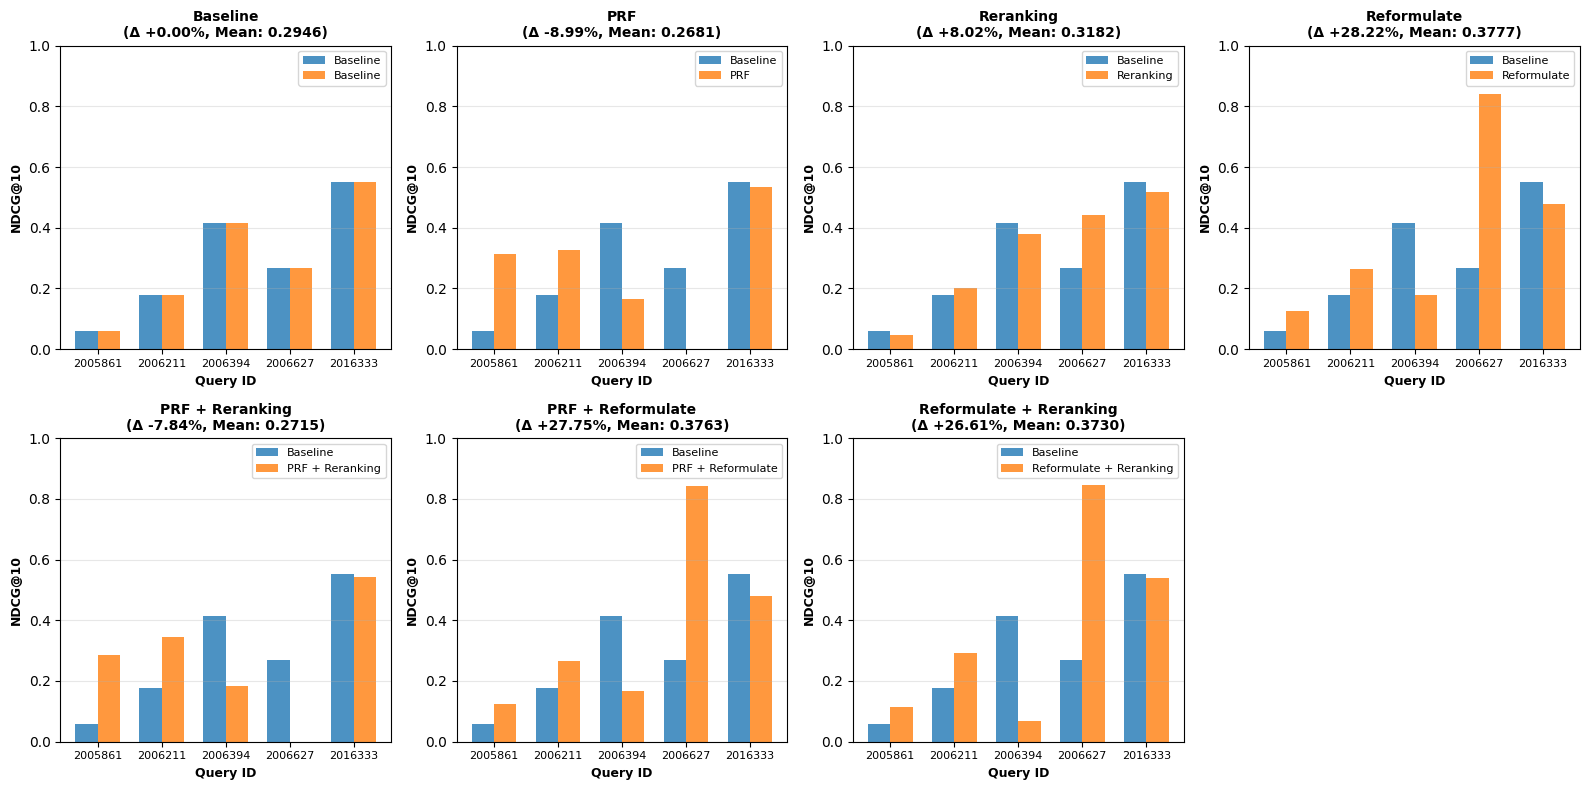


✓ All combination graphs generated successfully


In [13]:

# ============================================================================
# CELL 6: LOOP ALL COMBINATIONS - Compare all agent combinations
# ============================================================================

# Define all valid combinations
all_combinations = [
    ([0, 0, 0], "Baseline"),
    ([1, 0, 0], "PRF"),
    ([0, 1, 0], "Reranking"),
    ([0, 0, 1], "Reformulate"),
    ([1, 1, 0], "PRF + Reranking"),
    ([1, 0, 1], "PRF + Reformulate"),
    ([0, 1, 1], "Reformulate + Reranking")
]

# Store results for all combinations
all_results = {}

print("\n" + "="*80)
print("EVALUATING ALL AGENT COMBINATIONS")
print("="*80)

for combination, combo_name in all_combinations:
    print(f"\n{'='*80}")
    print(f"RUNNING: {combo_name}")
    print(f"{'='*80}")
    
    # Re-initialize agents for this combination
    temp_agents = {}
    if combination[0]:  # PRF
        temp_agents['PRF'] = PRFAgent(embed_model=encoder, num_expansion_terms=NUM_EXPANSION_TERMS)
    if combination[1]:  # Reranking
        temp_agents['Reranking'] = RerankingAgent(embed_model=encoder)
    if combination[2]:  # Reformulate
        temp_agents['Reformulate'] = ReformulationAgent(embed_model=encoder)
    
    # Temporarily update global agents dict for helper functions
    original_agents = agents.copy()
    agents.clear()
    agents.update(temp_agents)
    
    # Run agent combination pipeline
    combo_results_dict = {}
    combo_ndcg_scores = {}
    
    for query_id in sample_queries:
        query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
        query_text = query_row['query_text']
        
        # Start with baseline retrieval results
        baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
        
        # If no agents selected, use baseline
        if sum(combination) == 0:
            final_doc_ids = baseline_doc_ids
        else:
            current_doc_ids = baseline_doc_ids
            current_scores = baseline_scores
            current_corpus = baseline_corpus
            
            # Apply agents in order: Reformulate/PRF first, then Reranking
            if combination[2]:  # Reformulate (run first if selected)
                current_doc_ids, _ = apply_reformulate_agent(query_text, TOP_K)
                _, current_scores, current_corpus = retriever_func(query_text, top_k=TOP_K)
            
            elif combination[0]:  # PRF (run first if Reformulate not selected)
                current_doc_ids = apply_prf_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
            
            # Apply Reranking if selected (always last if selected with another agent)
            if combination[1] and (combination[0] or combination[2]):
                current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
            
            elif combination[1] and not combination[0] and not combination[2]:  # Reranking only
                current_doc_ids = apply_reranking_agent(query_text, baseline_doc_ids, baseline_scores, baseline_corpus, TOP_K)
            
            final_doc_ids = current_doc_ids
        
        # Create graded relevance list
        graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in final_doc_ids]
        combo_results_dict[query_id] = graded_relevance
        
        # Calculate NDCG
        ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
        combo_ndcg_scores[query_id] = ndcg
        print(f"  Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")
    
    # Store results
    combo_mean = np.mean(list(combo_ndcg_scores.values()))
    improvement = combo_mean - baseline_mean
    improvement_pct = (improvement / baseline_mean * 100) if baseline_mean > 0 else 0
    
    all_results[combo_name] = {
        'ndcg_scores': combo_ndcg_scores,
        'mean_ndcg': combo_mean,
        'improvement': improvement,
        'improvement_pct': improvement_pct
    }
    
    print(f"\nMean NDCG@{TOP_K}: {combo_mean:.4f}")
    print(f"Improvement vs Baseline: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    # Restore original agents dict
    agents.clear()
    agents.update(original_agents)

print("\n" + "="*80)
print("SUMMARY OF ALL COMBINATIONS")
print("="*80)

summary_data = []
for combo_name, results in all_results.items():
    summary_data.append({
        'Agent Combination': combo_name,
        'Mean NDCG': f"{results['mean_ndcg']:.4f}",
        'Improvement': f"{results['improvement']:+.4f}",
        'Improvement %': f"{results['improvement_pct']:+.2f}%"
    })

df_summary = pd.DataFrame(summary_data)
with pd.option_context('display.max_rows', None):
    print("\n" + df_summary.to_string(index=False))

print("\n" + "="*80)
print("GENERATING COMPARISON GRAPHS FOR EACH COMBINATION")
print("="*80)

# Create subplots for all combinations (2x4 grid)
n_combos = len(all_combinations)
n_cols = 4
n_rows = (n_combos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # Flatten for easier iteration

for idx, (combination, combo_name) in enumerate(all_combinations):
    results = all_results[combo_name]
    combo_ndcg_scores = results['ndcg_scores']
    combo_mean = results['mean_ndcg']
    improvement_pct = results['improvement_pct']
    
    ax = axes[idx]
    
    # Prepare data
    query_ids_str = [str(qid) for qid in sample_queries]
    baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
    agent_scores = [combo_ndcg_scores[qid] for qid in sample_queries]
    
    x = np.arange(len(query_ids_str))
    width = 0.35
    
    # Create bar chart
    ax.bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
    ax.bar(x + width/2, agent_scores, width, label=combo_name, alpha=0.8, color='#ff7f0e')
    
    # Format
    ax.set_xlabel('Query ID', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'NDCG@{TOP_K}', fontsize=9, fontweight='bold')
    ax.set_title(f'{combo_name}\n(Δ {improvement_pct:+.2f}%, Mean: {combo_mean:.4f})', 
                 fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(query_ids_str, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])

# Hide unused subplots
for idx in range(n_combos, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ All combination graphs generated successfully")


In [ ]:

# ============================================================================
# CELL 7: PRF EXPANSION TERMS ANALYSIS - Loop expansion terms 1-10
# ============================================================================

print("\n" + "="*80)
print("PRF AGENT: EXPANSION TERMS ANALYSIS (1-10)")
print("="*80)

# Store results for all expansion terms
expansion_results = {}

# Loop through expansion terms
for num_terms in range(1, 11):
    print(f"\n{'='*80}")
    print(f"RUNNING: PRF with {num_terms} expansion terms")
    print(f"{'='*80}")
    
    # Initialize PRF agent with current expansion term count
    temp_agents = {'PRF': PRFAgent(embed_model=encoder, num_expansion_terms=num_terms)}
    
    # Temporarily update global agents dict
    original_agents = agents.copy()
    agents.clear()
    agents.update(temp_agents)
    
    # Run PRF agent pipeline
    term_ndcg_scores = {}
    
    for query_id in sample_queries:
        query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
        query_text = query_row['query_text']
        
        # Get baseline retrieval results
        baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
        
        # Apply PRF agent
        prf_doc_ids = apply_prf_agent(query_text, baseline_doc_ids, baseline_scores, baseline_corpus, TOP_K)
        
        # Create graded relevance list
        graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in prf_doc_ids]
        
        # Calculate NDCG
        ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
        term_ndcg_scores[query_id] = ndcg
        print(f"  Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")
    
    # Store results
    term_mean = np.mean(list(term_ndcg_scores.values()))
    improvement = term_mean - baseline_mean
    improvement_pct = (improvement / baseline_mean * 100) if baseline_mean > 0 else 0
    
    expansion_results[num_terms] = {
        'ndcg_scores': term_ndcg_scores,
        'mean_ndcg': term_mean,
        'improvement': improvement,
        'improvement_pct': improvement_pct
    }
    
    print(f"\nMean NDCG@{TOP_K}: {term_mean:.4f}")
    print(f"Improvement vs Baseline: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    # Restore original agents dict
    agents.clear()
    agents.update(original_agents)

print("\n" + "="*80)
print("SUMMARY: PRF EXPANSION TERMS (1-10)")
print("="*80)

summary_data = []
for num_terms, results in expansion_results.items():
    summary_data.append({
        'Expansion Terms': num_terms,
        'Mean NDCG': f"{results['mean_ndcg']:.4f}",
        'Improvement': f"{results['improvement']:+.4f}",
        'Improvement %': f"{results['improvement_pct']:+.2f}%"
    })

df_expansion_summary = pd.DataFrame(summary_data)
with pd.option_context('display.max_rows', None):
    print("\n" + df_expansion_summary.to_string(index=False))

print("\n" + "="*80)
print("GENERATING COMPARISON GRAPHS FOR EACH EXPANSION TERM")
print("="*80)

# Create subplots for all expansion terms (2x5 grid)
n_terms = 10
n_cols = 5
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axes = axes.flatten()

for idx, num_terms in enumerate(range(1, 11)):
    results = expansion_results[num_terms]
    term_ndcg_scores = results['ndcg_scores']
    term_mean = results['mean_ndcg']
    improvement_pct = results['improvement_pct']
    
    ax = axes[idx]
    
    # Prepare data
    query_ids_str = [str(qid) for qid in sample_queries]
    baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
    agent_scores = [term_ndcg_scores[qid] for qid in sample_queries]
    
    x = np.arange(len(query_ids_str))
    width = 0.35
    
    # Create bar chart
    ax.bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
    ax.bar(x + width/2, agent_scores, width, label=f'{num_terms} terms', alpha=0.8, color='#ff7f0e')
    
    # Format
    ax.set_xlabel('Query ID', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'NDCG@{TOP_K}', fontsize=9, fontweight='bold')
    ax.set_title(f'PRF: {num_terms} Expansion Terms\n(Δ {improvement_pct:+.2f}%, Mean: {term_mean:.4f})', 
                 fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(query_ids_str, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

print("\n✓ All expansion term graphs generated successfully")

# ===== LINE PLOT: MEAN NDCG vs EXPANSION TERMS =====
print("\nGenerating mean NDCG trend plot...")

fig, ax = plt.subplots(figsize=(10, 6))

expansion_terms = list(expansion_results.keys())
mean_ndcgs = [expansion_results[t]['mean_ndcg'] for t in expansion_terms]

ax.plot(expansion_terms, mean_ndcgs, marker='o', linewidth=2, markersize=8, color='#ff7f0e', label='PRF Mean NDCG')
ax.axhline(y=baseline_mean, color='#1f77b4', linestyle='--', linewidth=2, label=f'Baseline Mean NDCG ({baseline_mean:.4f})')

ax.set_xlabel('Number of Expansion Terms', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Mean NDCG@{TOP_K}', fontsize=12, fontweight='bold')
ax.set_title('PRF Performance: Impact of Expansion Terms', fontsize=13, fontweight='bold')
ax.set_xticks(expansion_terms)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Trend plot generated successfully")



PRF AGENT: EXPANSION TERMS ANALYSIS (1-10)

RUNNING: PRF with 1 expansion terms


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2005861: NDCG@10 = 0.1003


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2006211: NDCG@10 = 0.3302


...

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2006627: NDCG@10 = 0.0000


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Query 2016333: NDCG@10 = 0.5341

Mean NDCG@10: 0.2681
Improvement vs Baseline: -0.0265 (-8.99%)

RUNNING: PRF with 3 expansion terms


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
